In [2]:
import pandas as pd

In [2]:
df = pd.read_csv(f"Coffee Shop Sales.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.shape

(149116, 11)

<Axes: ylabel='Density'>

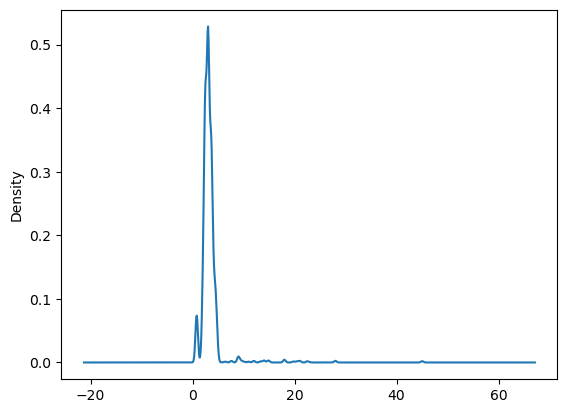

In [6]:
df['unit_price'].plot(kind='kde')

In [9]:
# !pip install mysql.connector
!pip install pymysql


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# import mysql.connector
import pymysql

In [3]:
import os
password = os.environ['password']

In [12]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password=password,
    host="localhost",
    port=3306,
    database="coffee_shop_db"
)

engine = create_engine(url)

df.to_sql("coffee", con=engine, index=False)

149116

In [4]:
conn = pymysql.connect(host='localhost',user='root',password=password,database='coffee_shop_db')

In [5]:
df = pd.read_sql_query("SELECT * FROM coffee_sales",conn)

C:\Users\badal\AppData\Local\Temp\ipykernel_30132\3963502760.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM coffee_sales",conn)


In [6]:
df.shape

(149116, 16)

In [7]:
df.head()

,transaction_id,transaction_date,order_month,order_dow,order_hour,day_type,day_part,store_location,product_category,product_type,product_detail,order_size,price_tier,transaction_qty,unit_price,revenue
0,1,2023-01-01,2023-01,Sunday,7,Weekend,Morning,Lower Manhattan,Coffee,Gourmet brewed coffee,Ethiopia Rg,small,medium,2,3.0,6.0
1,2,2023-01-01,2023-01,Sunday,7,Weekend,Morning,Lower Manhattan,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,small,medium,2,3.1,6.2
2,3,2023-01-01,2023-01,Sunday,7,Weekend,Morning,Lower Manhattan,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,small,high,2,4.5,9.0
3,4,2023-01-01,2023-01,Sunday,7,Weekend,Morning,Lower Manhattan,Coffee,Drip coffee,Our Old Time Diner Blend Sm,small,low,1,2.0,2.0
4,5,2023-01-01,2023-01,Sunday,7,Weekend,Morning,Lower Manhattan,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,small,medium,2,3.1,6.2


In [9]:
df.to_csv('coffee_sales_updated.csv',index=False)